In [1]:
import time
start_time = time.time()

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import json
import pandas as pd
import sys
from pathlib import Path
import os


In [3]:
# Add path to py_modules 
sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root

# Add path to pipeline_config.py
sys.path.append(str(Path().resolve().parents[0]))  # 1 level up = project root

# Import from pipeline_config and py_modules
from pipeline_config import RESULTS_DIR

import bfunc

In [4]:
data_in = [
    'S_III-9069_mask_0_bin_0',
    'S_III-9069_mask_bin_2', 
    'S_III-9069_mask_bin_4',
    'S_III-9069_mask_bin_8',
    'S_III-9069_mask_bin_16'  # flux_thresh = 0.001
]


In [5]:
colors = plt.cm.viridis(np.linspace(0, 1, len(data_in)))

In [6]:
# --- Load Data ---
data = {}
results_type = 'results_2sig'
results_type_ = 'preres'

for name in data_in:
    with open(RESULTS_DIR/f'{name}.json') as f:
        json_data = json.load(f)

    data[name] = {
        'B':     np.array(json_data["B"]),
        'r':     np.array(json_data["r"]),
        'sig2':  json_data[results_type]['sig2'][0],
        'r0':    json_data[results_type]['r0'][0],
        'm':     json_data[results_type]['m'][0],
        's0':    json_data[results_type]['s0'][0],
        'noise': json_data[results_type]['noise'][0],
        'sig2_': json_data[results_type_]['sig2'],
    }

In [7]:
#data['H_I-6563']

In [8]:
#markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X', 'h', 'H', 'd']
markers = ['o', 'o', 'o', 'o', 'o', '+', '+', '+','s',  's', 's', 's', '.','.','.','.']


# --- Annotation coordinates (custom per dataset) ---




In [9]:
annot_x = 10


log_y_positions = np.logspace(1.5, .5, len(data_in))  # from high to low
annotation_coords = {
    name: (annot_x, y)
    for name, y in zip(data_in, log_y_positions)
}

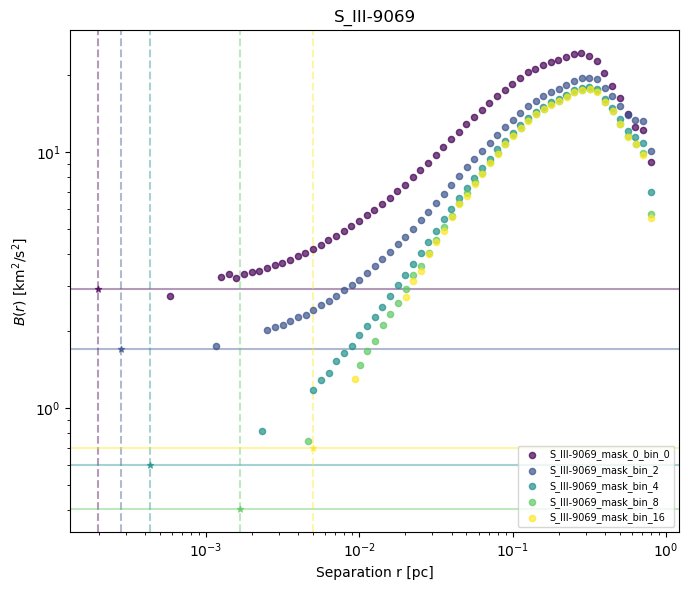

In [10]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))
rgrid = np.logspace(-4, 0.8)

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]

    ax.axhline(d['noise'], ls='-', color=color, alpha=0.4)
    ax.axvline(d['s0'], ls='--', color=color, alpha=0.4)

    ax.scatter(d['s0'], d['noise'], color=color, zorder=10, alpha=0.7, s=20, marker = '*')
    ax.scatter(d['r'], d['B'], label=name, color=color, zorder=10, alpha=0.7, s=20)

#    ax.plot(rgrid, bfunc.bfunc03s(rgrid, d['r0'], d['sig2'], d['m'], d['s0'], d['noise']), color=color, ls=':')
#    ax.plot(rgrid, bfunc.bfunc00s(rgrid, d['r0'], d['sig2'], d['m']), color=color, ls='--', alpha=0.7)

#    if 'sig2_' in d:
#        ax.axhline(d['sig2_'], ls='-', color=color, alpha=0.3)

    # Annotate m
#    ax.text(
#        d['r0'] * 1.2, d['sig2'] * 0.75,
#        f"$m = {d['m']:.2f}$", color=color,
#        fontsize=8, bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3')
#    )

ax.plot(d['s0'], d['noise'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title('S_III-9069')
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
#plt.savefig('figures/orion_structure_functions_variants.png', dpi=300)
plt.show()


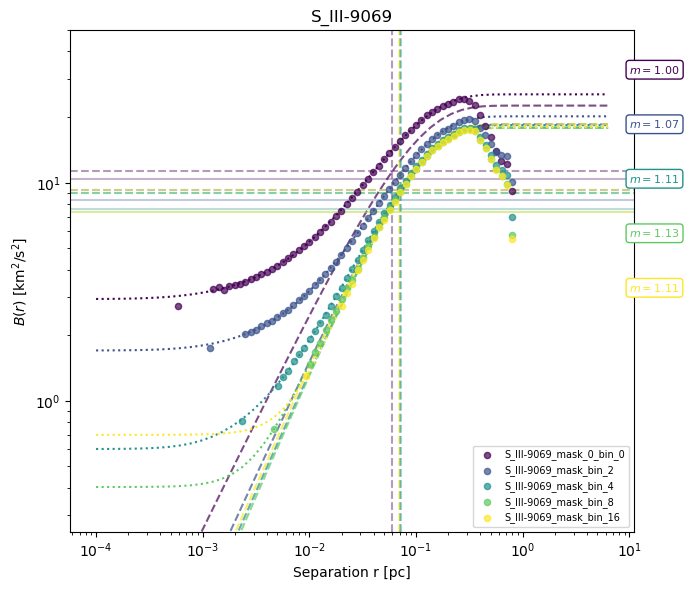

In [11]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))
rgrid = np.logspace(-4, 0.8)

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]
    marker = markers[i % len(markers)]

    ax.axhline(d['sig2'], ls='--', color=color, alpha=0.4)
    ax.axvline(d['r0'], ls='--', color=color, alpha=0.4)

    ax.scatter(d['r'], d['B'], label=name, color=color, zorder=10, alpha=0.7, s=20, marker=marker)

    ax.plot(rgrid, bfunc.bfunc03s(rgrid, d['r0'], d['sig2'], d['m'], d['s0'], d['noise']), color=color, ls=':')
    ax.plot(rgrid, bfunc.bfunc00s(rgrid, d['r0'], d['sig2'], d['m']), color=color, ls='--', alpha=0.7)

    if 'sig2_' in d:
        ax.axhline(d['sig2_'], ls='-', color=color, alpha=0.3)

    # Annotate m
    x_annot, y_annot = annotation_coords[name]
    ax.text(
        x_annot, y_annot, f"$m = {d['m']:.2f}$", color=color,
        fontsize=8, bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3')
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title('S_III-9069')
ax.legend(loc='lower right', fontsize=7)
ax.set_ylim(0.25,50)

plt.tight_layout()
#plt.savefig('orion_structure_functions_variants.png', dpi=300)
plt.show()
